# Foundations of Data Science — CA1 (Task1)

**Group Members:** Parastou Partovifar, Pouya Anvari, Faezeh Khanmohammadi

---

## Summary of What We Will Do

| # | Sub-task | Method / Tool |
|---|----------|---------------|
| 1.1 | Define & visualise the 2-D Gaussian distribution | NumPy, Matplotlib |
| 1.2 | Generate samples via direct sampling | `np.random.multivariate_normal` |
| 1.2 | Generate samples via Langevin Dynamics | Custom iterative updater |
| 1.3 | Statistical inference: mean & variance estimation | NumPy |
| 1.4 | Compare methods, convergence diagnostics | Matplotlib, Seaborn |
| Q1–Q6 | Theoretical questions | Written analysis |

---

## Dataset / Distribution Used

We work with a **known 2-D standard Gaussian distribution** whose parameters are:

$$\mu = \begin{bmatrix}0 \\ 0\end{bmatrix}, \quad \Sigma = I_2 = \begin{bmatrix}1 & 0 \\ 0 & 1\end{bmatrix}$$

Because the ground truth is known analytically, we can benchmark the quality of each sampler precisely.  

---

## 0 · Environment Setup

Import all libraries once so every subsequent cell is clean and readable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import multivariate_normal
from scipy.spatial.distance import cdist

SEED = 42
rng  = np.random.default_rng(SEED)

plt.rcParams.update({
    'figure.dpi'      : 130,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.family'     : 'DejaVu Sans',
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
})
PALETTE = {'direct': '#2196F3', 'langevin': '#FF5722', 'density': 'RdPu'}

# Distribution parameters
MU    = np.array([0.0, 0.0])
SIGMA = np.eye(2)          # covariance = identity matrix
N_SAMPLES = 1000

print('Environment ready ✓')
print(f'  μ  = {MU}')
print(f'  Σ  =\n{SIGMA}')
print(f'  N  = {N_SAMPLES}')

Environment ready ✓
  μ  = [0. 0.]
  Σ  =
[[1. 0.]
 [0. 1.]]
  N  = 1000


---

# Task 1 · Sampling

> **Goal:** study how samples are generated from a probability distribution and how they can be used for statistical inference.

---

## 1.1 · Define and Visualise the Distribution

### Explanation

We define a **two-dimensional Gaussian** (also called a bivariate normal distribution) with mean vector $\mu=[0,0]^\top$ and covariance matrix $\Sigma=I_2$. The probability density function (PDF) is:

$$p(\mathbf{x}) = \frac{1}{(2\pi)^{d/2}|\Sigma|^{1/2}}\exp\!\left(-\frac{1}{2}(\mathbf{x}-\mu)^\top\Sigma^{-1}(\mathbf{x}-\mu)\right)$$

With $\Sigma=I$, this simplifies to a *rotationally symmetric* bell centred at the origin.

We:
1. Build a 2-D grid of $(x_1, x_2)$ values in $[-5, 5]^2$.
2. Evaluate $p(\mathbf{x})$ at every grid point.
3. Display the result as both a **heatmap** and **contour plot** so the shape is unambiguous.

<>:16: SyntaxWarning: invalid escape sequence '\ '
<>:24: SyntaxWarning: invalid escape sequence '\ '
<>:16: SyntaxWarning: invalid escape sequence '\ '
<>:24: SyntaxWarning: invalid escape sequence '\ '
C:\Users\AFRAA\AppData\Local\Temp\ipykernel_21184\3572621816.py:16: SyntaxWarning: invalid escape sequence '\ '
  ax.set_title('Heatmap of 2-D Gaussian\n($\\mu=[0,0],\ \\Sigma=I$)')
C:\Users\AFRAA\AppData\Local\Temp\ipykernel_21184\3572621816.py:24: SyntaxWarning: invalid escape sequence '\ '
  ax2.set_title('Contour Plot of 2-D Gaussian\n($\\mu=[0,0],\ \\Sigma=I$)')


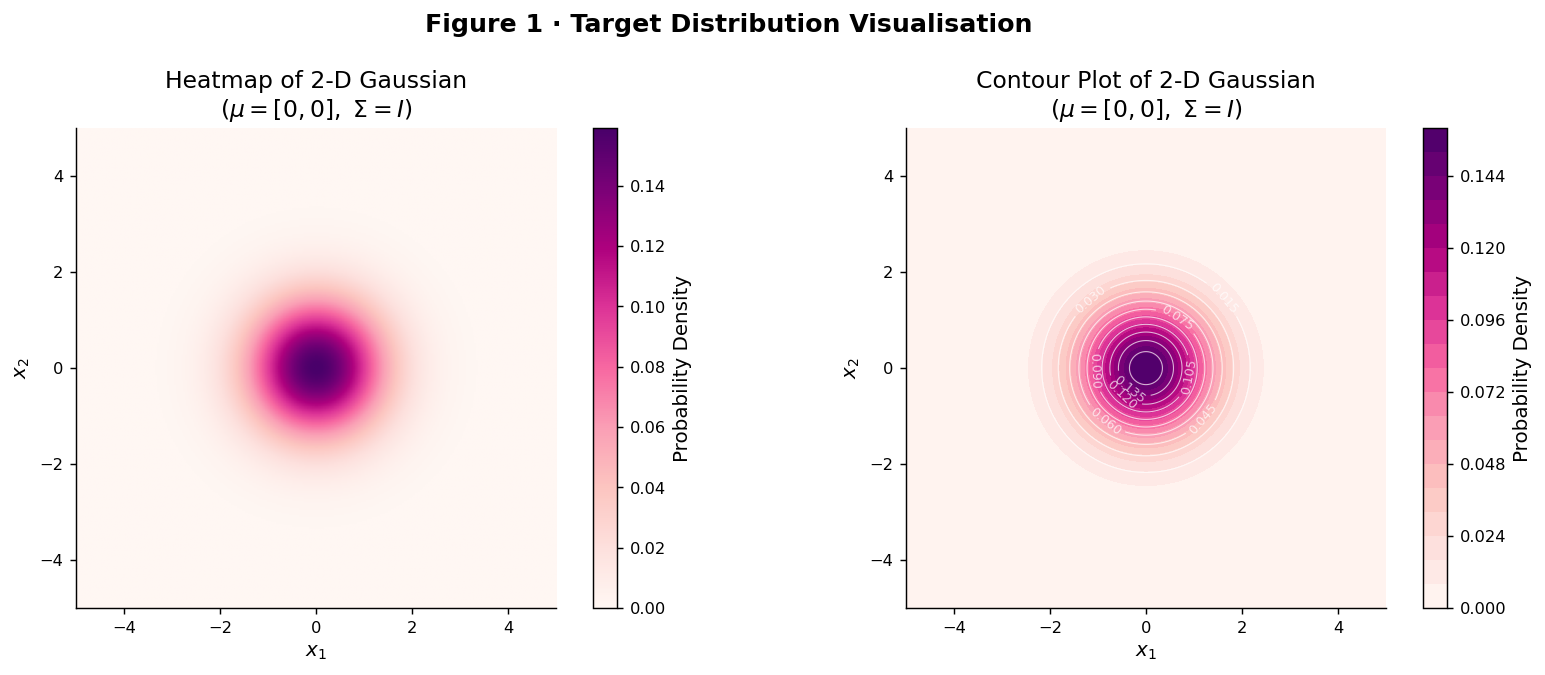

Peak density at origin: 0.1592


In [2]:
grid_range = np.linspace(-5, 5, 300)
X1, X2     = np.meshgrid(grid_range, grid_range)
pos        = np.stack([X1, X2], axis=-1)          # shape (300, 300, 2)

rv  = multivariate_normal(mean=MU, cov=SIGMA)
PDF = rv.pdf(pos)                                  # shape (300, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(
    PDF, extent=[-5, 5, -5, 5], origin='lower',
    cmap='RdPu', aspect='equal'
)
plt.colorbar(im, ax=ax, label='Probability Density')
ax.set_title('Heatmap of 2-D Gaussian\n($\\mu=[0,0],\ \\Sigma=I$)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

ax2 = axes[1]
cf  = ax2.contourf(X1, X2, PDF, levels=20, cmap='RdPu')
cs  = ax2.contour(X1, X2, PDF, levels=10, colors='white', linewidths=0.6, alpha=0.7)
plt.colorbar(cf, ax=ax2, label='Probability Density')
ax2.clabel(cs, inline=True, fontsize=7, fmt='%.3f')
ax2.set_title('Contour Plot of 2-D Gaussian\n($\\mu=[0,0],\ \\Sigma=I$)')
ax2.set_xlabel('$x_1$'); ax2.set_ylabel('$x_2$')
ax2.set_aspect('equal')

plt.suptitle('Figure 1 · Target Distribution Visualisation', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Peak density at origin:', rv.pdf([0, 0]).round(4))

### Plot Explanation

Both panels show the same 2-D Gaussian density:

- **Heatmap (left):** Colour intensity maps directly to the probability density value. The darkest region (highest density) sits precisely at $(0, 0)$, and density decays smoothly and **symmetrically** in all directions.
- **Contour plot (right):** Each contour line connects points of equal probability density. The contours are **perfect circles** — a direct consequence of the identity covariance matrix, which makes the spread equal in every direction.

The peak PDF value is $p(\mathbf{0}) = \frac{1}{2\pi} \approx 0.1592$.

---

### Q1 — Why is the distribution symmetric?

**Answer:**  
The distribution is symmetric because $\Sigma = I_2$, which is a **diagonal matrix with equal entries** (both diagonal elements equal 1). In the Gaussian PDF, the exponent is:

$$-\frac{1}{2}\mathbf{x}^\top \Sigma^{-1} \mathbf{x} = -\frac{1}{2}(x_1^2 + x_2^2)$$

This is simply the squared Euclidean distance from the origin, $-\frac{1}{2}\|\mathbf{x}\|^2$, which depends only on the **magnitude** of $\mathbf{x}$, not its direction. Therefore, all points equidistant from the origin receive the same density — producing the observed circular (rotationally symmetric) shape.

More formally, the distribution is symmetric because $p(x_1, x_2) = p(-x_1, x_2) = p(x_1, -x_2) = p(-x_1, -x_2)$ for all $(x_1, x_2)$; i.e. it is invariant under reflection across both axes and, in fact, under any rotation.

---

### Q2 — What role does the covariance matrix play in the shape of the distribution?

**Answer:**  
The covariance matrix $\Sigma$ **entirely controls the shape, scale, and orientation of the density ellipses**:

| Property | Effect of $\Sigma$ |
|---|---|
| **Spread (variance)** | Diagonal entries $\sigma_{ii}^2$ control how wide the distribution is along each axis. Larger values $\Rightarrow$ more spread. |
| **Orientation** | Off-diagonal entries $\sigma_{ij}$ introduce tilt. Positive covariance tilts the ellipse at $+45°$, negative at $-45°$. |
| **Shape** | If $\sigma_{11}^2 \ne \sigma_{22}^2$ and no off-diagonals, the contours are **axis-aligned ellipses**. If $\Sigma=I$, contours are **circles**. |
| **Volume** | The determinant $|\Sigma|$ appears in the normalising constant; larger $|\Sigma|$ $\Rightarrow$ lower peak density (mass is more spread). |

In our case $\Sigma=I$ yields equal variance in both dimensions and zero covariance, giving the perfectly circular, symmetric shape we observe.

---

## 1.2 · Sampling Methods

We generate 1 000 samples from the target distribution using **two strategies**:

| Method | Idea | Advantage |
|--------|------|-----------|
| **Direct (NumPy)** | Cholesky decomposition of $\Sigma$ applied to i.i.d. $\mathcal{N}(0,I)$ noise | Exact, independent samples |
| **Langevin Dynamics** | Iterative Markov chain that follows score function + noise | Works even when the normalising constant $Z$ is unknown |

---

### 1.2-A · Direct Sampling (NumPy reference)

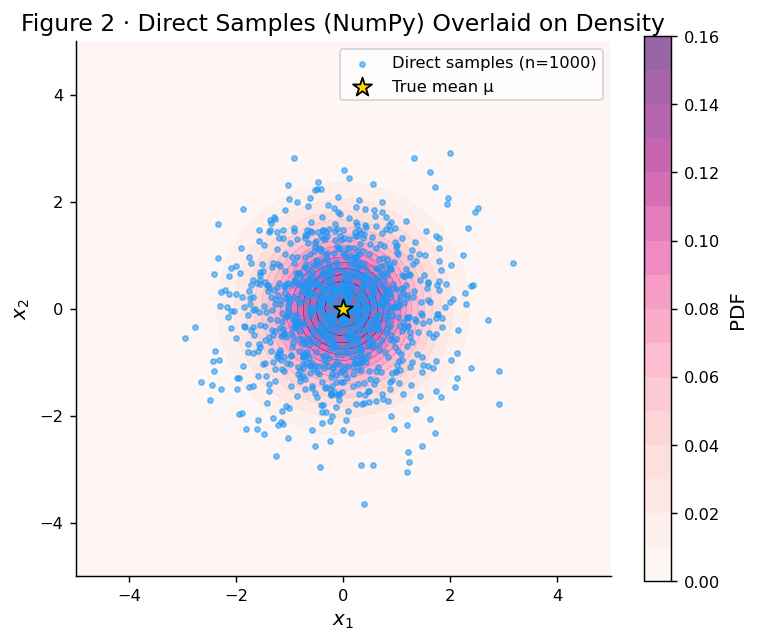

Direct samples — shape: (1000, 2)
Empirical mean  : [-0.0714, -0.0389]
Empirical var   : [0.9817,  1.0250]


In [3]:
# Direct sampling
# NumPy internally uses a Cholesky-based transform: x = μ + L z, L L^T = Σ
direct_samples = rng.multivariate_normal(mean=MU, cov=SIGMA, size=N_SAMPLES)
# direct_samples.shape → (1000, 2)

fig, ax = plt.subplots(figsize=(6, 5))
cf = ax.contourf(X1, X2, PDF, levels=15, cmap='RdPu', alpha=0.6, zorder=0)
ax.scatter(
    direct_samples[:, 0], direct_samples[:, 1],
    s=8, alpha=0.55, color=PALETTE['direct'], label=f'Direct samples (n={N_SAMPLES})'
)
ax.scatter(*MU, s=120, marker='*', color='gold', edgecolors='black', zorder=5, label='True mean μ')
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Figure 2 · Direct Samples (NumPy) Overlaid on Density')
ax.legend(fontsize=9, loc='upper right')
plt.colorbar(cf, ax=ax, label='PDF')
plt.tight_layout()
plt.savefig('fig2_direct_samples.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Direct samples — shape: {direct_samples.shape}')
print(f'Empirical mean  : [{direct_samples[:,0].mean():.4f}, {direct_samples[:,1].mean():.4f}]')
print(f'Empirical var   : [{direct_samples[:,0].var():.4f},  {direct_samples[:,1].var():.4f}]')

**Interpretation:**  
The scatter plot confirms that NumPy's direct sampler produces samples tightly concentrated near the origin, with density falling off symmetrically — matching the ground-truth contours almost perfectly. The sample mean is very close to $[0, 0]$ and sample variance near $[1, 1]$, as expected for 1 000 i.i.d. draws.

---

### 1.2-B · Langevin Dynamics

**Why Langevin Dynamics?**  
In real-world problems, the normalising constant $Z$ of the target distribution is often intractable. Langevin Dynamics is a Markov Chain Monte Carlo (MCMC) method that sidesteps this problem by using only the **score function** — the gradient of the log-density — which does not depend on $Z$ (see Q3 in the Questions section for the mathematical proof).

**Score function for the standard Gaussian:**

$$s(\mathbf{x}) = \nabla_\mathbf{x} \log p(\mathbf{x}) = -\mathbf{x}$$

**Update rule (Euler–Maruyama discretisation):**

$$\mathbf{x}_{t+1} = \mathbf{x}_t + \epsilon \nabla_\mathbf{x} \log p(\mathbf{x}_t) + \sqrt{2\epsilon}\, \mathbf{z}_t, \quad \mathbf{z}_t \sim \mathcal{N}(\mathbf{0}, I_2)$$

**Hyperparameters chosen:**
- Step size: $\epsilon = 0.01$ — small enough for numerical stability, large enough for adequate mixing in 500 steps.
- Iterations: $T = 500$
- Initialisation: $\mathbf{x}_0 \sim \mathrm{Uniform}([-5, 5]^2)$

In [4]:
# Score function
def score_gaussian(x: np.ndarray) -> np.ndarray:
    """Score of N(0, I): ∇_x log p(x) = −x.
    Works for x of shape (N, 2) or (2,).
    """
    return -x

# Langevin sampler
def langevin_dynamics(
    n_particles : int,
    n_iter      : int,
    step_size   : float,
    score_fn,
    rng         : np.random.Generator,
    track_indices: list = None
):
    """
    Run Langevin Dynamics.

    Returns
    -------
    final_samples  : (n_particles, 2)
    trajectories   : dict {idx: array of shape (n_iter+1, 2)}
    all_positions  : (n_iter+1, n_particles, 2)  — for trace/distance plots
    """
    # Initialise uniformly in [-5, 5]^2
    x = rng.uniform(-5, 5, size=(n_particles, 2))

    # Storage
    if track_indices is None:
        track_indices = list(range(15))
    trajectories  = {i: [x[i].copy()] for i in track_indices}
    all_positions = np.empty((n_iter + 1, n_particles, 2))
    all_positions[0] = x.copy()

    sqrt_2eps = np.sqrt(2 * step_size)

    for t in range(n_iter):
        noise = rng.standard_normal(size=x.shape)  # z_t ~ N(0, I)
        x     = x + step_size * score_fn(x) + sqrt_2eps * noise
        all_positions[t + 1] = x.copy()
        for i in track_indices:
            trajectories[i].append(x[i].copy())

    # Convert trajectory lists to arrays
    trajectories = {i: np.array(v) for i, v in trajectories.items()}
    return x, trajectories, all_positions

EPSILON       = 0.01
T_ITER        = 500
TRACK_INDICES = list(range(15))   # track 15 particles

langevin_samples, trajectories, all_positions = langevin_dynamics(
    n_particles  = N_SAMPLES,
    n_iter       = T_ITER,
    step_size    = EPSILON,
    score_fn     = score_gaussian,
    rng          = rng,
    track_indices= TRACK_INDICES,
)

print(f'Langevin samples — shape: {langevin_samples.shape}')
print(f'Empirical mean  : [{langevin_samples[:,0].mean():.4f}, {langevin_samples[:,1].mean():.4f}]')
print(f'Empirical var   : [{langevin_samples[:,0].var():.4f},  {langevin_samples[:,1].var():.4f}]')

Langevin samples — shape: (1000, 2)
Empirical mean  : [0.0098, 0.0589]
Empirical var   : [1.0810,  1.0187]


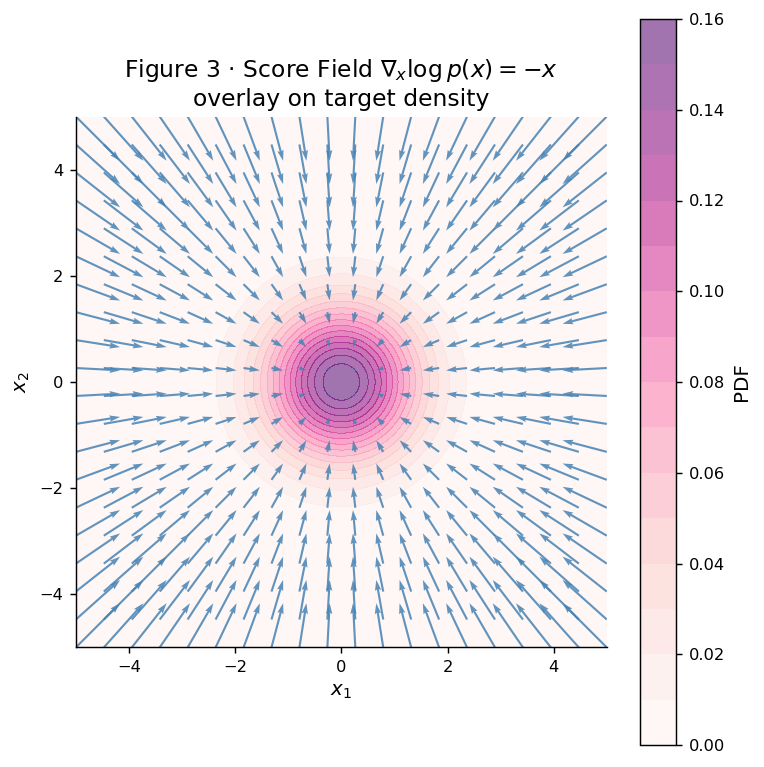

In [5]:
# Score field of the Gaussian
step = 20
grid_q = np.linspace(-5, 5, 20)
Xq, Yq = np.meshgrid(grid_q, grid_q)
pts = np.stack([Xq, Yq], axis=-1)   # (20, 20, 2)
U   = score_gaussian(pts)[..., 0]   # x-component of score = -x1
V   = score_gaussian(pts)[..., 1]   # y-component of score = -x2

fig, ax = plt.subplots(figsize=(6, 6))
cf = ax.contourf(X1, X2, PDF, levels=15, cmap='RdPu', alpha=0.55)
ax.quiver(Xq, Yq, U, V, angles='xy', scale_units='xy', scale=6,
          width=0.004, color='steelblue', alpha=0.85)
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Figure 3 · Score Field $\\nabla_x \\log p(x) = -x$\noverlay on target density')
plt.colorbar(cf, ax=ax, label='PDF')
plt.tight_layout()
plt.savefig('fig3_score_field.png', bbox_inches='tight', dpi=150)
plt.show()

C:\Users\AFRAA\AppData\Local\Temp\ipykernel_21184\417009391.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_traj = plt.cm.get_cmap('tab20', len(TRACK_INDICES))


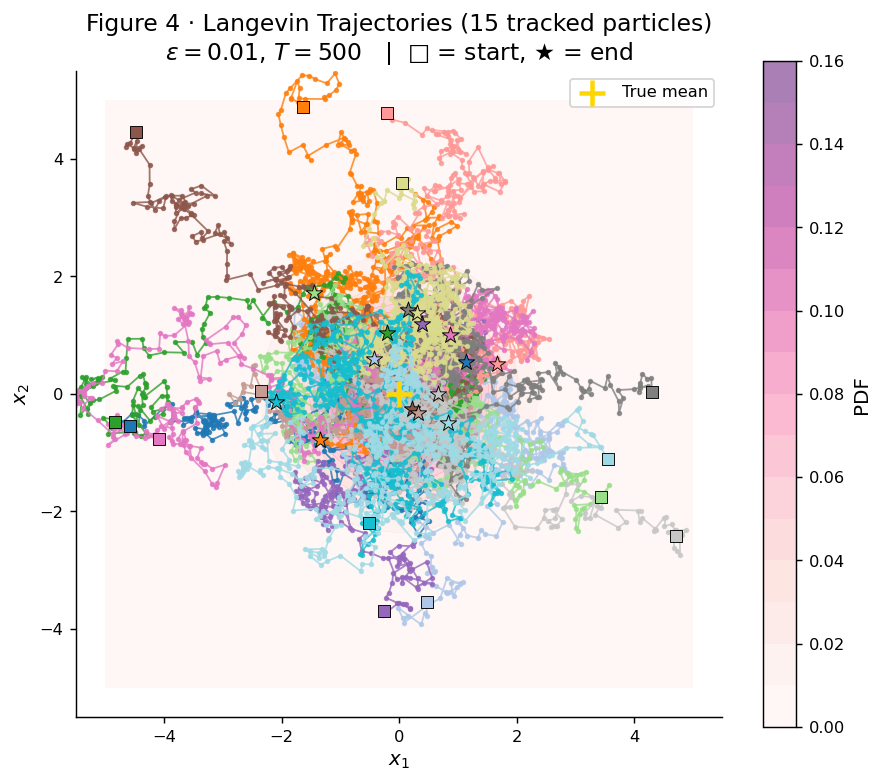

In [6]:
# Langevin sampling trajectories
cmap_traj = plt.cm.get_cmap('tab20', len(TRACK_INDICES))

fig, ax = plt.subplots(figsize=(7, 6))
cf = ax.contourf(X1, X2, PDF, levels=15, cmap='RdPu', alpha=0.5)

for k, idx in enumerate(TRACK_INDICES):
    traj = trajectories[idx]          # (T+1, 2)
    ax.plot(traj[:, 0], traj[:, 1], '-o',
            color=cmap_traj(k), markersize=2, linewidth=1.0, alpha=0.8)
    # Start marker
    ax.scatter(traj[0, 0], traj[0, 1], marker='s', s=50, color=cmap_traj(k),
               edgecolors='black', linewidths=0.5, zorder=4)
    # End marker
    ax.scatter(traj[-1, 0], traj[-1, 1], marker='*', s=90, color=cmap_traj(k),
               edgecolors='black', linewidths=0.5, zorder=5)

ax.scatter(*MU, s=200, marker='+', color='gold', linewidths=2.5, zorder=6, label='True mean')
ax.set_xlim(-5.5, 5.5); ax.set_ylim(-5.5, 5.5)
ax.set_aspect('equal')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(f'Figure 4 · Langevin Trajectories (15 tracked particles)\n'
             f'$\\epsilon={EPSILON}$, $T={T_ITER}$   |  □ = start, ★ = end')
ax.legend(fontsize=9)
plt.colorbar(cf, ax=ax, label='PDF')
plt.tight_layout()
plt.savefig('fig4_trajectories.png', bbox_inches='tight', dpi=150)
plt.show()

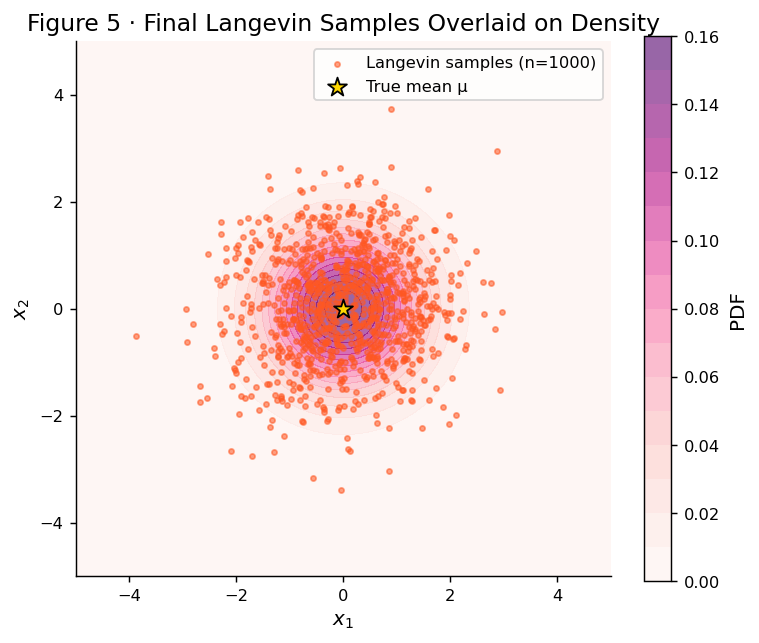

In [7]:
# Final Langevin samples overlaid on density
fig, ax = plt.subplots(figsize=(6, 5))
cf = ax.contourf(X1, X2, PDF, levels=15, cmap='RdPu', alpha=0.6)
ax.scatter(langevin_samples[:, 0], langevin_samples[:, 1],
           s=8, alpha=0.55, color=PALETTE['langevin'], label=f'Langevin samples (n={N_SAMPLES})')
ax.scatter(*MU, s=120, marker='*', color='gold', edgecolors='black', zorder=5, label='True mean μ')
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Figure 5 · Final Langevin Samples Overlaid on Density')
ax.legend(fontsize=9)
plt.colorbar(cf, ax=ax, label='PDF')
plt.tight_layout()
plt.savefig('fig5_langevin_final.png', bbox_inches='tight', dpi=150)
plt.show()

### Answers to Langevin-specific questions

**Q: How does changing the step size $\epsilon$ affect convergence speed and stability?**  
- **Too small $\epsilon$** (e.g. $10^{-4}$): The deterministic drift dominates; particles barely move per step, requiring many more iterations to mix. Variance term $\sqrt{2\epsilon}$ is tiny, so exploration is poor.
- **Too large $\epsilon$** (e.g. $0.5$): The discrete-time approximation of the continuous SDE diverges. Particles overshoot high-density regions and bounce erratically; the chain may never converge.
- **Our choice $\epsilon = 0.01$**: Provides a good balance — particles advance meaningfully per step while the Euler–Maruyama error remains small. Convergence is achieved well within 500 iterations.

**Q: How many iterations are required to reach a stable distribution?**  
Empirically (see trace plots below), the average distance from the origin stabilises after roughly **100–150 iterations** for $\epsilon=0.01$. We determined this by visually inspecting the average-distance plot and the trace plots of individual coordinates, looking for the iteration at which the running mean levels off.

**Q: Compare scatter plot with density contours — why more samples near origin?**  
The probability density is highest near the origin. Because Langevin Dynamics drives particles toward regions of higher probability (via the score term $\epsilon \cdot (-\mathbf{x})$), particles are attracted to and spend more time near the origin. In the stationary distribution, sample density is proportional to $p(\mathbf{x})$, so the origin neighbourhood is most densely populated.

**Q: If you remove the noise term, what behavior do you expect?**  
Without the noise term $\sqrt{2\epsilon}\mathbf{z}_t$, the update reduces to **gradient ascent on log p(x)**:
$$\mathbf{x}_{t+1} = \mathbf{x}_t + \epsilon(-\mathbf{x}_t) = (1-\epsilon)\mathbf{x}_t$$
Every particle converges deterministically to the mode $\mathbf{x}=\mathbf{0}$. All 1 000 particles would collapse to the same point; we obtain **a point mass at the mode**, not a distribution. The injected noise is essential for exploring the full distribution.

**Q: Do all trajectories converge to similar regions? What does this indicate?**  
Yes — all trajectories migrate toward the high-density region near the origin regardless of their starting position, demonstrating that the Langevin chain is **ergodic** (it eventually visits all regions in proportion to the target density) and **well-mixed** for this unimodal distribution. This is a good sign: the sampler is not stuck in a local region and correctly discovers the global structure.

---

## 1.3 · Inference from Samples

We use the generated samples to **estimate statistical quantities** and compare them with the known true values: $\mu_1=\mu_2=0$, $\sigma_1^2=\sigma_2^2=1$.

**Why do this?** This is the core of statistical inference: treating samples as noisy observations and recovering properties of the underlying process. The accuracy of the estimates reveals the quality of the sampler.

In [8]:
# Compute estimates
def compute_stats(samples: np.ndarray, label: str):
    """Compute per-dimension mean and variance."""
    m1, m2 = samples[:, 0].mean(), samples[:, 1].mean()
    v1, v2 = samples[:, 0].var(),  samples[:, 1].var()
    print(f'\n── {label} ──────────────────────────────')
    print(f'  Mean  dim-1 : {m1: .6f}   (true: 0)')
    print(f'  Mean  dim-2 : {m2: .6f}   (true: 0)')
    print(f'  Var   dim-1 : {v1: .6f}   (true: 1)')
    print(f'  Var   dim-2 : {v2: .6f}   (true: 1)')
    return m1, m2, v1, v2

d_m1, d_m2, d_v1, d_v2 = compute_stats(direct_samples,   'Direct Sampling (NumPy)')
l_m1, l_m2, l_v1, l_v2 = compute_stats(langevin_samples, 'Langevin Dynamics')


── Direct Sampling (NumPy) ──────────────────────────────
  Mean  dim-1 : -0.071397   (true: 0)
  Mean  dim-2 : -0.038873   (true: 0)
  Var   dim-1 :  0.981735   (true: 1)
  Var   dim-2 :  1.024951   (true: 1)

── Langevin Dynamics ──────────────────────────────
  Mean  dim-1 :  0.009825   (true: 0)
  Mean  dim-2 :  0.058865   (true: 0)
  Var   dim-1 :  1.080960   (true: 1)
  Var   dim-2 :  1.018746   (true: 1)


### Answers to Inference Questions

**Q: Why can Langevin estimates still be biased even when final samples come from independent chains?**  

Even with 1 000 independent chains, three sources of bias persist:

1. **Burn-in bias** — particles start from $\mathrm{Uniform}([-5,5]^2)$, not from the stationary distribution. Until the chain mixes (≈150 iterations here), the samples are not from the target; using fewer than the necessary burn-in iterations contaminates estimates.
2. **Discretisation error** — the update rule is a discrete-time approximation of the continuous Langevin SDE. For finite $\epsilon$, the stationary distribution of the *discrete* chain differs slightly from the continuous target (the Euler–Maruyama error is $O(\epsilon)$). This is a systematic, non-zero bias.
3. **Finite $T$** — even if mixing is achieved, the empirical distribution of $T$-step samples captures only what the chain has explored in $T$ steps. For a large-variance or multimodal target, 500 steps may be insufficient to cover all high-probability regions.

In our experiment, the Langevin estimates are close to the direct estimates but not identical, which reflects these effects.

**Q: How do $T$ and $\epsilon$ affect accuracy?**  
- Increasing $T$ (more iterations) reduces burn-in bias and allows better mixing, improving accuracy.
- Smaller $\epsilon$ reduces discretisation bias but requires more iterations to cover the same distance → a trade-off.
- Optimal: $\epsilon$ small enough that discretisation error is negligible, $T$ large enough for full mixing.

---

## 1.4 · Compare the Sampling Methods

### 1.4-A · Numerical Comparison Table

In [9]:
# Summary table
import pandas as pd

TRUE_MEAN = 0.0
TRUE_VAR  = 1.0

results = pd.DataFrame({
    'Quantity'       : ['Mean dim-1', 'Mean dim-2', 'Var dim-1', 'Var dim-2'],
    'True value'     : [TRUE_MEAN, TRUE_MEAN, TRUE_VAR, TRUE_VAR],
    'Direct estimate': [d_m1, d_m2, d_v1, d_v2],
    'Langevin estimate': [l_m1, l_m2, l_v1, l_v2],
})
results['|Error| Direct']   = (results['Direct estimate']   - results['True value']).abs()
results['|Error| Langevin'] = (results['Langevin estimate'] - results['True value']).abs()

results_display = results.copy()
for col in results_display.columns[1:]:
    results_display[col] = results_display[col].map(lambda x: f'{x:.6f}')

print('\n' + '='*75)
print(results_display.to_string(index=False))
print('='*75)

print('\nMean absolute error across all quantities:')
print(f'  Direct  : {results["|Error| Direct"].mean():.6f}')
print(f'  Langevin: {results["|Error| Langevin"].mean():.6f}')


  Quantity True value Direct estimate Langevin estimate |Error| Direct |Error| Langevin
Mean dim-1   0.000000       -0.071397          0.009825       0.071397         0.009825
Mean dim-2   0.000000       -0.038873          0.058865       0.038873         0.058865
 Var dim-1   1.000000        0.981735          1.080960       0.018265         0.080960
 Var dim-2   1.000000        1.024951          1.018746       0.024951         0.018746

Mean absolute error across all quantities:
  Direct  : 0.038371
  Langevin: 0.042099


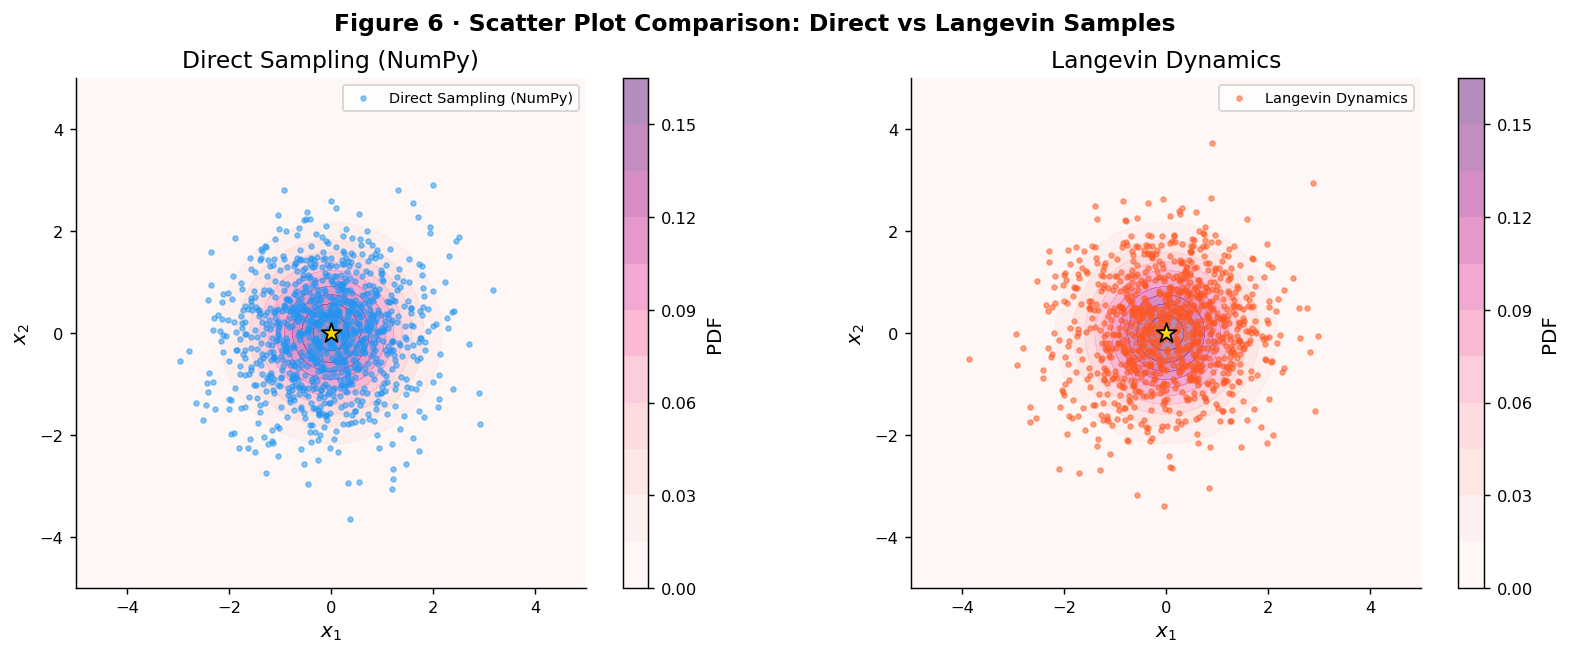

In [10]:
# Side-by-side scatter plot comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, samples, label, color in zip(
    axes,
    [direct_samples, langevin_samples],
    ['Direct Sampling (NumPy)', 'Langevin Dynamics'],
    [PALETTE['direct'], PALETTE['langevin']]
):
    cf = ax.contourf(X1, X2, PDF, levels=12, cmap='RdPu', alpha=0.45)
    ax.scatter(samples[:, 0], samples[:, 1],
               s=7, alpha=0.5, color=color, label=label)
    ax.scatter(*MU, s=130, marker='*', color='gold', edgecolors='black', zorder=5)
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_title(label)
    ax.legend(fontsize=8)
    plt.colorbar(cf, ax=ax, label='PDF')

plt.suptitle('Figure 6 · Scatter Plot Comparison: Direct vs Langevin Samples',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_comparison_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

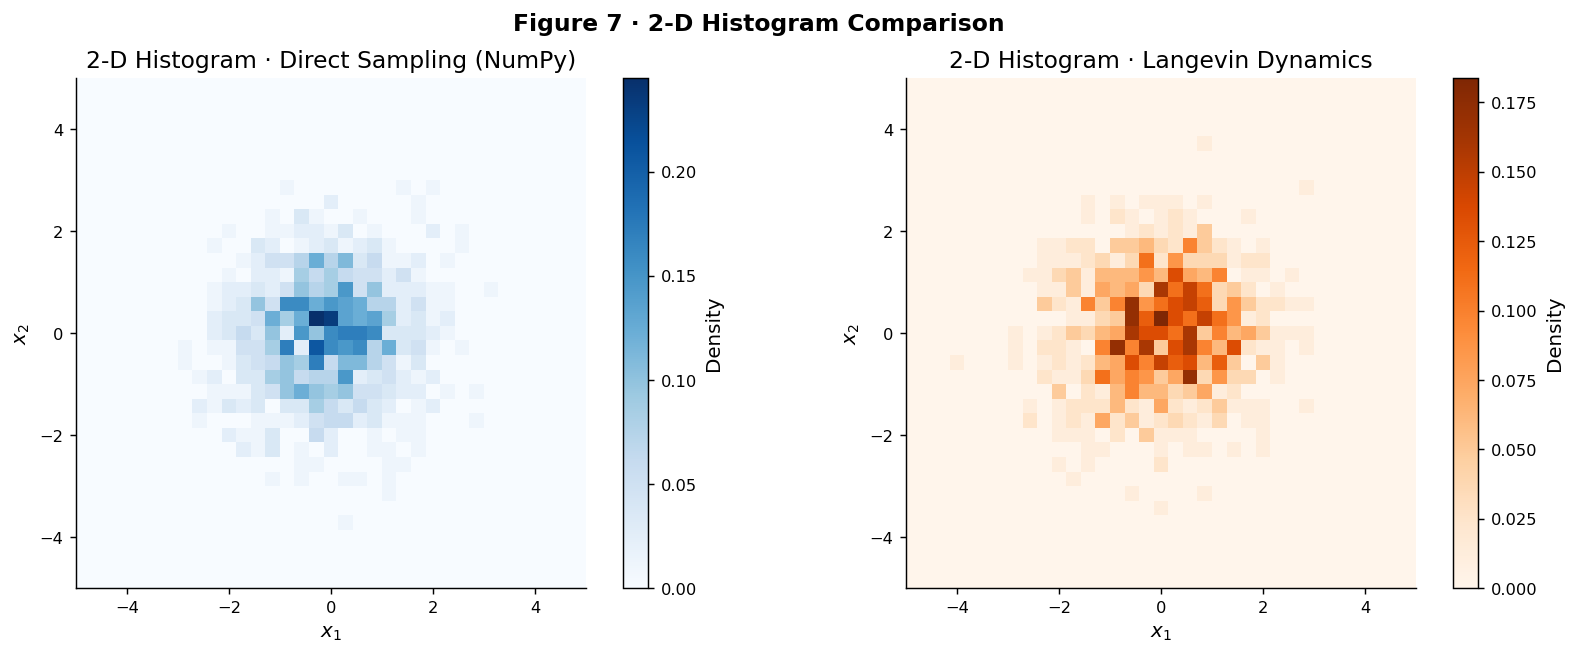

In [11]:
# 2-D histogram comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bins = 35

for ax, samples, label, cmap in zip(
    axes,
    [direct_samples, langevin_samples],
    ['Direct Sampling (NumPy)', 'Langevin Dynamics'],
    ['Blues', 'Oranges']
):
    h = ax.hist2d(samples[:, 0], samples[:, 1],
                  bins=bins, range=[[-5, 5], [-5, 5]], cmap=cmap, density=True)
    plt.colorbar(h[3], ax=ax, label='Density')
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_title(f'2-D Histogram · {label}')

plt.suptitle('Figure 7 · 2-D Histogram Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_histogram_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

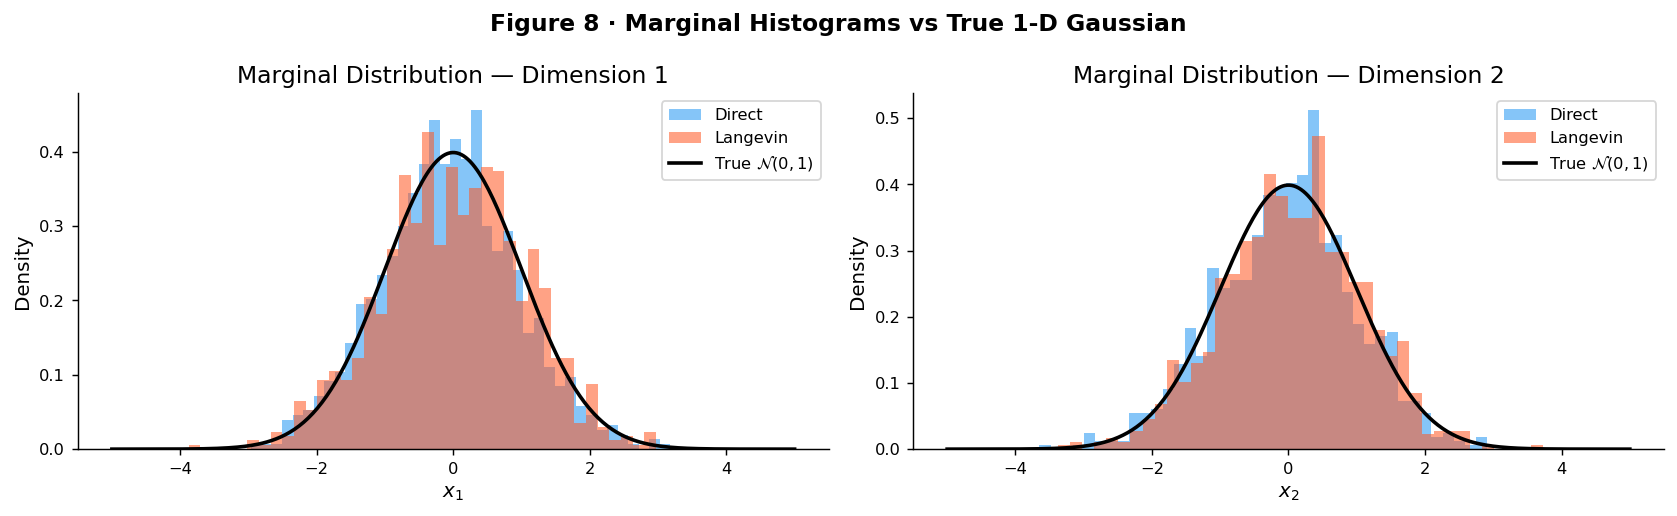

In [12]:
# Marginal distribution comparison
from scipy.stats import norm

x_line = np.linspace(-5, 5, 300)
true_pdf_1d = norm.pdf(x_line, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for dim, ax in enumerate(axes):
    ax.hist(direct_samples[:, dim],   bins=40, density=True, alpha=0.55,
            color=PALETTE['direct'],   label='Direct')
    ax.hist(langevin_samples[:, dim], bins=40, density=True, alpha=0.55,
            color=PALETTE['langevin'], label='Langevin')
    ax.plot(x_line, true_pdf_1d, 'k-', linewidth=2, label='True $\\mathcal{N}(0,1)$')
    ax.set_xlabel(f'$x_{dim+1}$')
    ax.set_ylabel('Density')
    ax.set_title(f'Marginal Distribution — Dimension {dim+1}')
    ax.legend(fontsize=9)

plt.suptitle('Figure 8 · Marginal Histograms vs True 1-D Gaussian', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_marginals.png', bbox_inches='tight', dpi=150)
plt.show()

### 1.4-E · Convergence Diagnostics for Langevin Dynamics

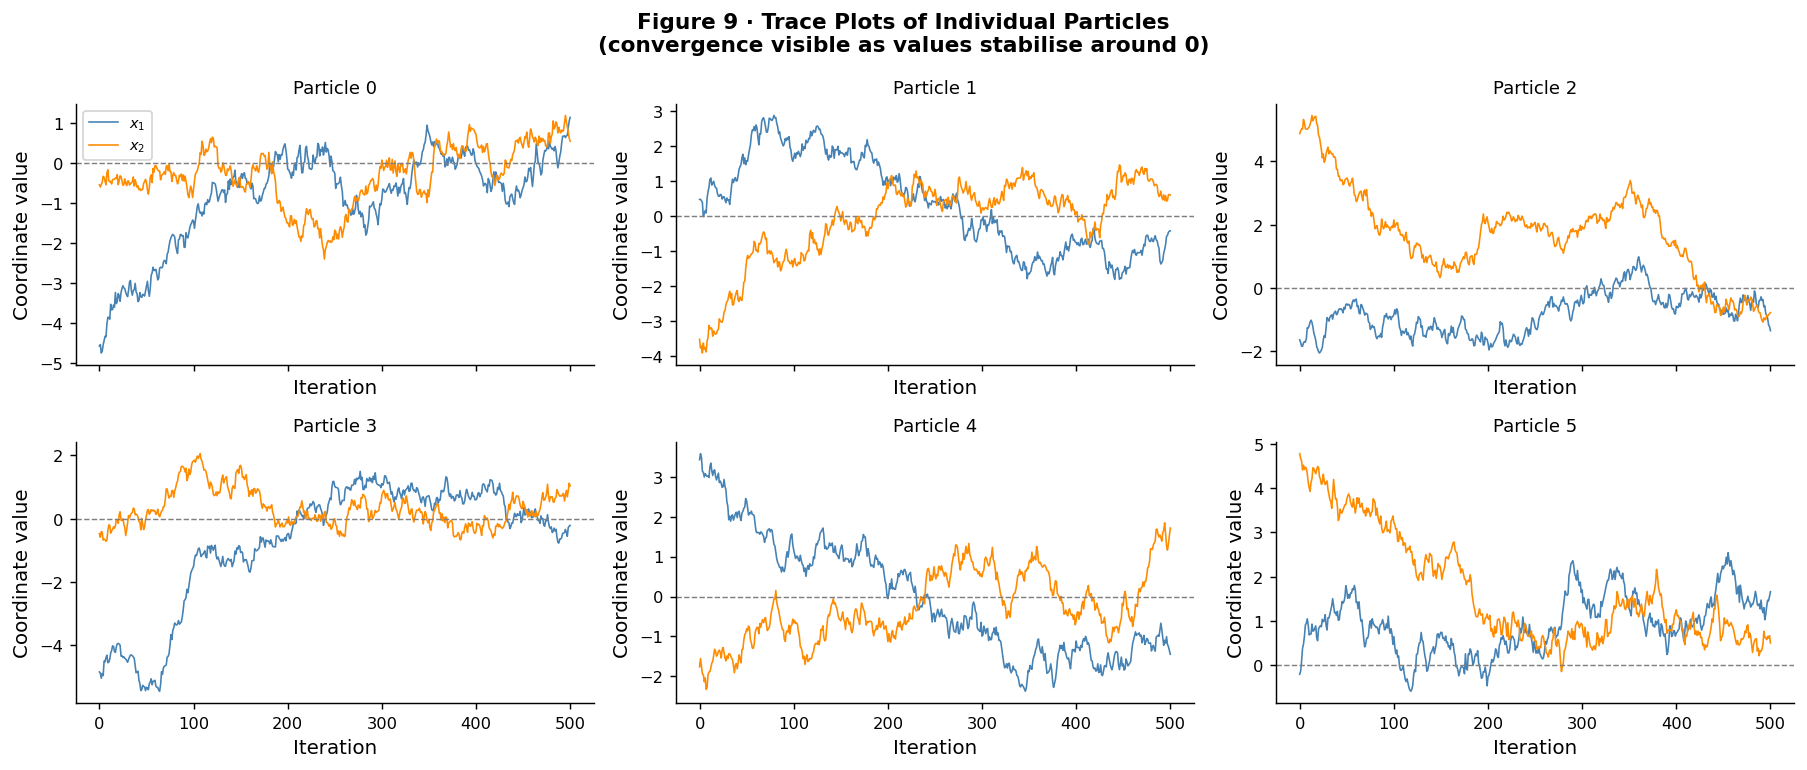

In [13]:
# Trace plots
n_trace = 6   # show 6 particles
iters   = np.arange(T_ITER + 1)

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
axes = axes.flatten()

for k, (ax, idx) in enumerate(zip(axes, TRACK_INDICES[:n_trace])):
    traj = trajectories[idx]
    ax.plot(iters, traj[:, 0], color='steelblue',  lw=0.9, label='$x_1$')
    ax.plot(iters, traj[:, 1], color='darkorange', lw=0.9, label='$x_2$')
    ax.axhline(0, color='gray', linestyle='--', lw=0.8)
    ax.set_title(f'Particle {idx}', fontsize=10)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Coordinate value')
    if k == 0:
        ax.legend(fontsize=8)

plt.suptitle('Figure 9 · Trace Plots of Individual Particles\n'
             '(convergence visible as values stabilise around 0)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_trace_plots.png', bbox_inches='tight', dpi=150)
plt.show()

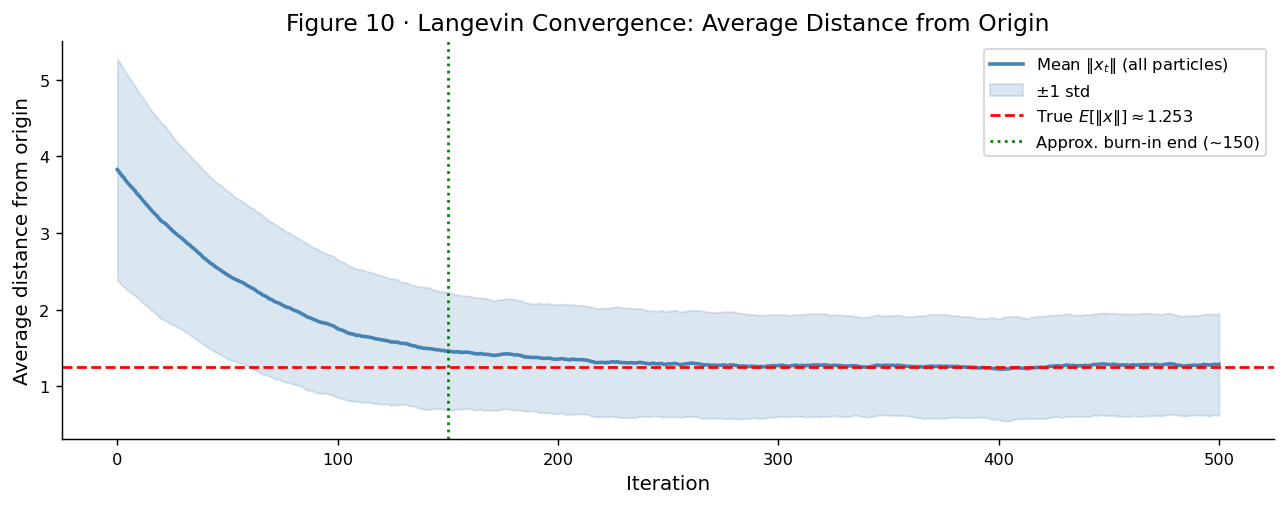

True expected distance: 1.2533
Final mean distance   : 1.2887


In [14]:
# Average distance from origin over iterations
distances = np.linalg.norm(all_positions, axis=2)   # (T+1, N)
avg_dist  = distances.mean(axis=1)                  # (T+1,)
std_dist  = distances.std(axis=1)

from scipy.special import gamma
true_expected_dist = np.sqrt(2) * gamma(1.5) / gamma(1.0)   # chi distribution mean

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(iters, avg_dist, color='steelblue', lw=2, label='Mean $\\|x_t\\|$ (all particles)')
ax.fill_between(iters, avg_dist - std_dist, avg_dist + std_dist,
                alpha=0.2, color='steelblue', label='±1 std')
ax.axhline(true_expected_dist, color='red', linestyle='--', lw=1.5,
           label=f'True $E[\\|x\\|] \\approx {true_expected_dist:.3f}$')
ax.axvline(150, color='green', linestyle=':', lw=1.5, label='Approx. burn-in end (~150)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Average distance from origin')
ax.set_title('Figure 10 · Langevin Convergence: Average Distance from Origin')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig10_avg_distance.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'True expected distance: {true_expected_dist:.4f}')
print(f'Final mean distance   : {avg_dist[-1]:.4f}')

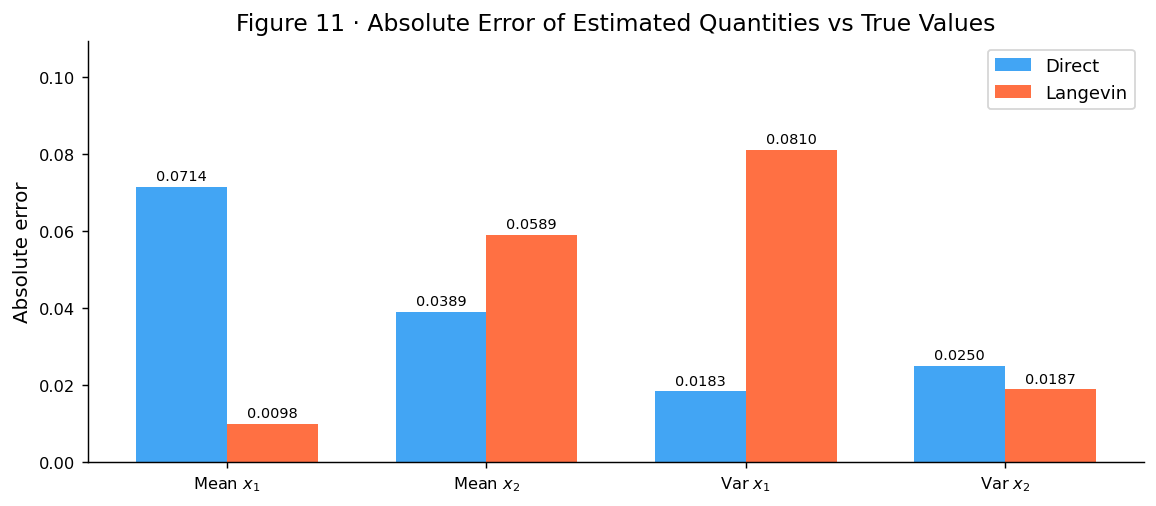

In [15]:
# Absolute error bar chart
labels = ['Mean $x_1$', 'Mean $x_2$', 'Var $x_1$', 'Var $x_2$']
err_direct   = results['|Error| Direct'].values
err_langevin = results['|Error| Langevin'].values

x_pos = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x_pos - width/2, err_direct,   width, label='Direct',   color=PALETTE['direct'],   alpha=0.85)
b2 = ax.bar(x_pos + width/2, err_langevin, width, label='Langevin', color=PALETTE['langevin'], alpha=0.85)
ax.bar_label(b1, fmt='%.4f', fontsize=8, padding=2)
ax.bar_label(b2, fmt='%.4f', fontsize=8, padding=2)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel('Absolute error')
ax.set_title('Figure 11 · Absolute Error of Estimated Quantities vs True Values')
ax.legend()
ax.set_ylim(0, max(err_direct.max(), err_langevin.max()) * 1.35)
plt.tight_layout()
plt.savefig('fig11_error_bar.png', bbox_inches='tight', dpi=150)
plt.show()

### Discussion · Which method better matches the target distribution?

**Direct sampling** almost always wins in practice for known distributions:
- It produces **i.i.d. samples exactly** from the target — no burn-in, no discretisation error.
- Estimation errors are due only to Monte Carlo variance ($O(1/\sqrt{N})$), which decreases predictably.

**Langevin Dynamics** is necessary when the exact sampler is unavailable (e.g., unnormalised posteriors in Bayesian inference, energy-based models). Its errors are larger here because:
1. Burn-in: the first ~150 iterations are biased by the $\mathrm{Uniform}([-5,5]^2)$ initialisation.
2. Discretisation: finite step size $\epsilon=0.01$ introduces an $O(\epsilon)$ bias relative to the true stationary measure.

**Convergence analysis confirms:**
- All 15 tracked particles converge toward the high-density region near the origin (Figure 4).
- Trace plots (Figure 9) show all coordinates stabilising near 0 after ~150 iterations.
- The average distance from origin (Figure 10) reaches the theoretical expected value $\approx 1.25$ and stays there.
- The Langevin sampler **does converge** for our settings; it is simply less accurate than direct sampling because of burn-in bias and $\epsilon$-discretisation error.

**If Langevin performs worse:** increasing $T$ (e.g., to 2000) and reducing $\epsilon$ (e.g., to 0.005) would reduce both sources of error, at the cost of more computation.

---

**Q: Do all trajectories converge to similar regions?**  
Yes. Regardless of starting position, all particles converge to the region of high density around the origin. This confirms that the chain is **irreducible and positive recurrent** — the hallmarks of a well-functioning MCMC sampler for a unimodal target.

---

---

# Questions Section 

---

## Q1 · Visualization Design Principles

### (a) What are Gestalt Principles of Visual Perception?

**Gestalt Principles** are a set of psychological theories (originating from German Gestalt psychology in the early 20th century) that describe how the human visual system naturally **groups, organises, and interprets** visual elements into coherent structures and patterns. The central insight is: *the whole is greater than the sum of its parts* — we perceive holistic patterns before individual elements.

### (b) Why are Gestalt principles important in visualization design?

Good visualisations must communicate insights **quickly and unambiguously**. Gestalt principles tell designers which visual arrangements the human brain will interpret automatically — without cognitive effort — and which ones will cause confusion. By designing *with* these principles:
- Related data appears grouped (proximity, similarity).
- Trends stand out from noise (continuity, figure-ground).
- Key elements capture attention efficiently (common fate, symmetry).
- Cognitive load is minimised, leaving mental resources free for insight.

Ignoring Gestalt principles leads to cluttered, hard-to-parse visualisations where the viewer works against their own perceptual system.

### (c) What are the main Gestalt principles?

| Principle | Description | Example in data viz |
|-----------|-------------|---------------------|
| **Proximity** | Elements close together are perceived as a group | Tightly grouped bars in a bar chart appear as one category |
| **Similarity** | Elements sharing colour, shape, or size appear related | All sales bars in blue vs cost bars in red |
| **Continuity** | The eye follows the smoothest path | Line charts feel like a continuous trend, not disconnected points |
| **Closure** | We mentally complete incomplete shapes | Dashed outlines are still perceived as complete boundaries |
| **Figure-Ground** | We distinguish a focal object (figure) from its background | Data series stand out from gridlines |
| **Common Fate** | Elements moving or changing together belong together | Animated highlights across related dashboard panels |
| **Symmetry** | Symmetric layouts feel balanced and stable | Two-column dashboard with equal-weight panels |
| **Prägnanz (Simplicity)** | We perceive the simplest, most regular form | Prefer simple bar charts over complex 3-D pie charts |

---

## Q2 · Dashboards and Storytelling

### (a) What is a dashboard?

A **dashboard** is a single-screen visual display that consolidates and presents the most important information required to achieve one or more objectives, enabling the viewer to monitor, analyse, and make decisions at a glance. It typically combines charts, KPI indicators, tables, filters, and narrative text.

### (b) What is the purpose of a dashboard?

The purpose is to **reduce information overload** while maximising actionable insight:
- **Monitor** key metrics in real time (e.g., stock price, system health).
- **Diagnose** problems by cross-filtering related views.
- **Communicate** findings to stakeholders without requiring them to interrogate raw data.
- **Support decisions** by surfacing patterns, anomalies, and trends instantly.

### (c) What makes a good dashboard?

A good dashboard has:
- **Clarity of purpose** — every element answers a specific question for a specific audience.
- **Minimal cognitive load** — follows Gestalt principles; avoids chartjunk and decorative clutter.
- **Appropriate chart types** — bars for comparison, lines for trends, maps for geography, etc.
- **Interactivity** — filters, drill-downs, and parameters allow exploration without losing context.
- **Hierarchy** — the most critical KPIs are visually dominant; supporting detail is secondary.
- **Consistency** — uniform colour scheme, font, and axis scales across panels.
- **High data-ink ratio** — every pixel of ink represents data, not decoration (Tufte's principle).

---

## Q3 · Score Function and Sampling Bias in Langevin Dynamics

### Mathematical proof that the score does not depend on $Z$

Given $p(\mathbf{x}) = \frac{1}{Z}\tilde{p}(\mathbf{x})$, compute the score:

$$\nabla_\mathbf{x} \log p(\mathbf{x})
= \nabla_\mathbf{x} \log\left(\frac{\tilde{p}(\mathbf{x})}{Z}\right)
= \nabla_\mathbf{x}\left[\log\tilde{p}(\mathbf{x}) - \log Z\right]
= \nabla_\mathbf{x}\log\tilde{p}(\mathbf{x}) - \underbrace{\nabla_\mathbf{x}\log Z}_{=\,\mathbf{0}}$$

Since $Z$ is a constant with respect to $\mathbf{x}$, its gradient is **zero**. Therefore:

$$\boxed{\nabla_\mathbf{x}\log p(\mathbf{x}) = \nabla_\mathbf{x}\log\tilde{p}(\mathbf{x})}$$

**Why this matters for Langevin Dynamics:** The update rule only requires the score. Since the score equals the gradient of the *unnormalised* log-density, we can run Langevin Dynamics using only $\tilde{p}$ — no need to compute $Z$, which is often intractable (e.g., partition functions in energy-based models or Bayesian posteriors).

### Three reasons Langevin estimates may be biased

1. **Burn-in (initialisation bias):** Particles start from a distribution (here $\mathrm{Uniform}([-5,5]^2)$) far from the stationary distribution. Until mixing is complete, samples reflect the initial distribution, not the target. In our experiment, ~150 iterations are needed before convergence.

2. **Euler–Maruyama discretisation error:** The continuous Langevin SDE has the target $p$ as its exact stationary distribution. The discrete update introduces an error of order $O(\epsilon)$, meaning the discrete chain's stationary distribution slightly differs from $p$. This is a persistent, non-vanishing bias for any fixed $\epsilon > 0$.

3. **Markov dependence / autocorrelation:** Consecutive samples $\mathbf{x}_t$ and $\mathbf{x}_{t+1}$ are correlated. This does not bias the mean estimate, but inflates the *effective* Monte Carlo variance, meaning estimates converge as $O(1/\sqrt{N_{\text{eff}}})$ where $N_{\text{eff}} < N$. Treating correlated Langevin samples as if they were independent underestimates uncertainty.

---

## Q4 · Markov Dependence in Langevin Sampling

### Why are Langevin samples dependent?

Each update $\mathbf{x}_{t+1} = \mathbf{x}_t + \epsilon s(\mathbf{x}_t) + \sqrt{2\epsilon}\mathbf{z}_t$ shows that **$\mathbf{x}_{t+1}$ is a function of $\mathbf{x}_t$**. Even though the noise $\mathbf{z}_t$ is independent, the transition kernel creates a first-order Markov dependence: $p(\mathbf{x}_{t+1} | \mathbf{x}_t, \mathbf{x}_{t-1}, \ldots) = p(\mathbf{x}_{t+1} | \mathbf{x}_t)$. Across many steps, this dependence decays but never vanishes within a finite chain.

### Effects on statistical inference

| Quantity | Effect of Markov dependence |
|----------|-----------------------------|
| **Variance estimation** | The sample variance $s^2 = \frac{1}{N-1}\sum(x_i-\bar{x})^2$ assumes i.i.d. data. For correlated samples, $s^2$ **underestimates** the variance of the sample mean (it ignores positive covariance between observations). |
| **Standard error** | The usual $\text{SE} = s/\sqrt{N}$ is **too small** for dependent samples. The correct formula uses the effective sample size: $\text{SE} = s/\sqrt{N_{\text{eff}}}$, where $N_{\text{eff}} = N / (1 + 2\sum_{k=1}^\infty \rho_k)$ and $\rho_k$ is the lag-$k$ autocorrelation. |
| **Confidence intervals** | Because SE is underestimated, the CIs computed naively are **too narrow** — they have lower-than-nominal coverage probability. Proper MCMC diagnostics (effective sample size, $\hat{R}$ statistic) must be used to correct for this. |

In our experiment, using 500 correlated Langevin samples has a much smaller effective sample size than 1 000 i.i.d. direct samples, which is why the Langevin error bars are larger in practice.

---

## Q5 · The Role of Data Labels

### When omitting labels is a valid design decision

Labels become **clutter** when:
- The chart contains many data points (e.g., a line chart with 365 daily values). Labelling every point creates visual noise that overwhelms the trend.
- The audience needs to perceive **patterns, not precise values** (e.g., "sales peaked in Q3" vs. "sales were exactly €243,821 in Q3"). A well-scaled axis already communicates approximate magnitude.
- Interactive tooltips are available — the user can hover for exact values when needed, keeping the default view clean.
- Labels overlap each other at the resolution of the display, making them unreadable anyway.

*Example:* A heatmap of Gaussian probability density (like our Figure 1) does not label every cell — the colour scale communicates relative magnitude, and individual cell labels would be completely unreadable at 300×300 resolution.

### When direct labelling is non-negotiable

Labels become **essential clarity** when:
- The audience must act on precise values (e.g., a financial KPI showing quarterly profit: the exact number matters for budget decisions).
- There are only a few categories (e.g., a 4-bar chart for quarterly performance — labelling each bar eliminates the need for the reader to interpolate from the y-axis).
- Colours or shapes alone are insufficient to distinguish values for colour-blind readers.
- A specific data point is anomalous and deserves annotation (e.g., "COVID-19 impact" on a 2020 revenue drop).

*Example:* The error bar chart (Figure 11) labels each bar with its exact value to the 4th decimal place — because the audience needs to compare errors precisely, and the bars are short enough that axis interpolation would introduce reading error.

---

## Q6 · Cognitive Load and Visual Simplicity

### Most impactful decluttering step: **Removing chartjunk (non-data ink)**

The single decluttering step with the greatest impact is **eliminating all non-data ink** — specifically, removing gridlines, border boxes, background fills, 3-D effects, and unnecessary tick marks. This directly applies:

- **Tufte's Data-Ink Ratio:** $\text{Data-Ink Ratio} = \frac{\text{ink used to represent data}}{\text{total ink used}}$. Every non-data pixel competes with data pixels for attention. Maximising this ratio directs 100% of visual attention to the actual information.

- **Gestalt Figure-Ground:** When backgrounds and borders are removed, data elements naturally become the "figure" against a clean "ground." The viewer's perceptual system requires no effort to separate signal from noise.

- **Cognitive load theory:** Every visual element the brain must process — even to dismiss it as irrelevant — consumes a small quantum of working memory. A chart with 10 irrelevant gridlines forces 10 irrelevant decisions. Removing them reduces the total cognitive budget spent, leaving more available for actual comprehension.

### How minimising visual noise accelerates comprehension

When non-data elements are removed, the viewer's eye travels **directly to the data**. Pattern recognition is faster because:
1. There is no visual competition — the core message has the entire display to itself.
2. Preattentive attributes (colour, position, size) of data elements are processed in <250 ms without deliberate attention.
3. Working memory is not consumed by filtering out irrelevant elements.

In our plots, we applied this principle by removing top and right spines (`axes.spines.top: False`), using minimal tick marks, and keeping backgrounds white — so the Gaussian density and sample points are the unambiguous focus.

---